In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split


In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
features = ["pclass","sex","fare","embarked","age"]
target= ["survived"]

In [7]:
#handling missing value
from sklearn.impute import SimpleImputer

imp_median  = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy= "most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [8]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


do encoding if categorical data and scalling for numerical data


In [9]:
# encoding
from sklearn.preprocessing  import LabelEncoder

le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])


In [10]:
x = titanic[features]
y = titanic[target]

In [11]:
x.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
x_train.head()

,pclass,sex,fare,embarked,age
331,1,1,28.5000,2,45.5
733,2,1,13.0000,2,23.0
382,3,1,7.9250,2,32.0
704,3,1,7.8542,2,26.0
813,3,0,31.2750,2,6.0


In [14]:
# decission tree model - no pruning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(x_train,y_train)


DecisionTreeClassifier()

In [29]:
from sklearn.metrics import classification_report,accuracy_score

y_pred = model.predict(x_test)
y_pred_1 = model.predict(x_train)

print("Trainnng score : ", accuracy_score(y_train,y_pred_1)*100, "%")
print("Testing score : ", accuracy_score(y_test,y_pred)*100, "%")
print(f"classification_report  =  {classification_report(y_test,y_pred)}")

Trainnng score :  62.35955056179775 %
Testing score :  58.659217877094974 %
classification_report  =                precision    recall  f1-score   support

           0       0.59      1.00      0.74       105
           1       0.00      0.00      0.00        74

    accuracy                           0.59       179
   macro avg       0.29      0.50      0.37       179
weighted avg       0.34      0.59      0.43       179



c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


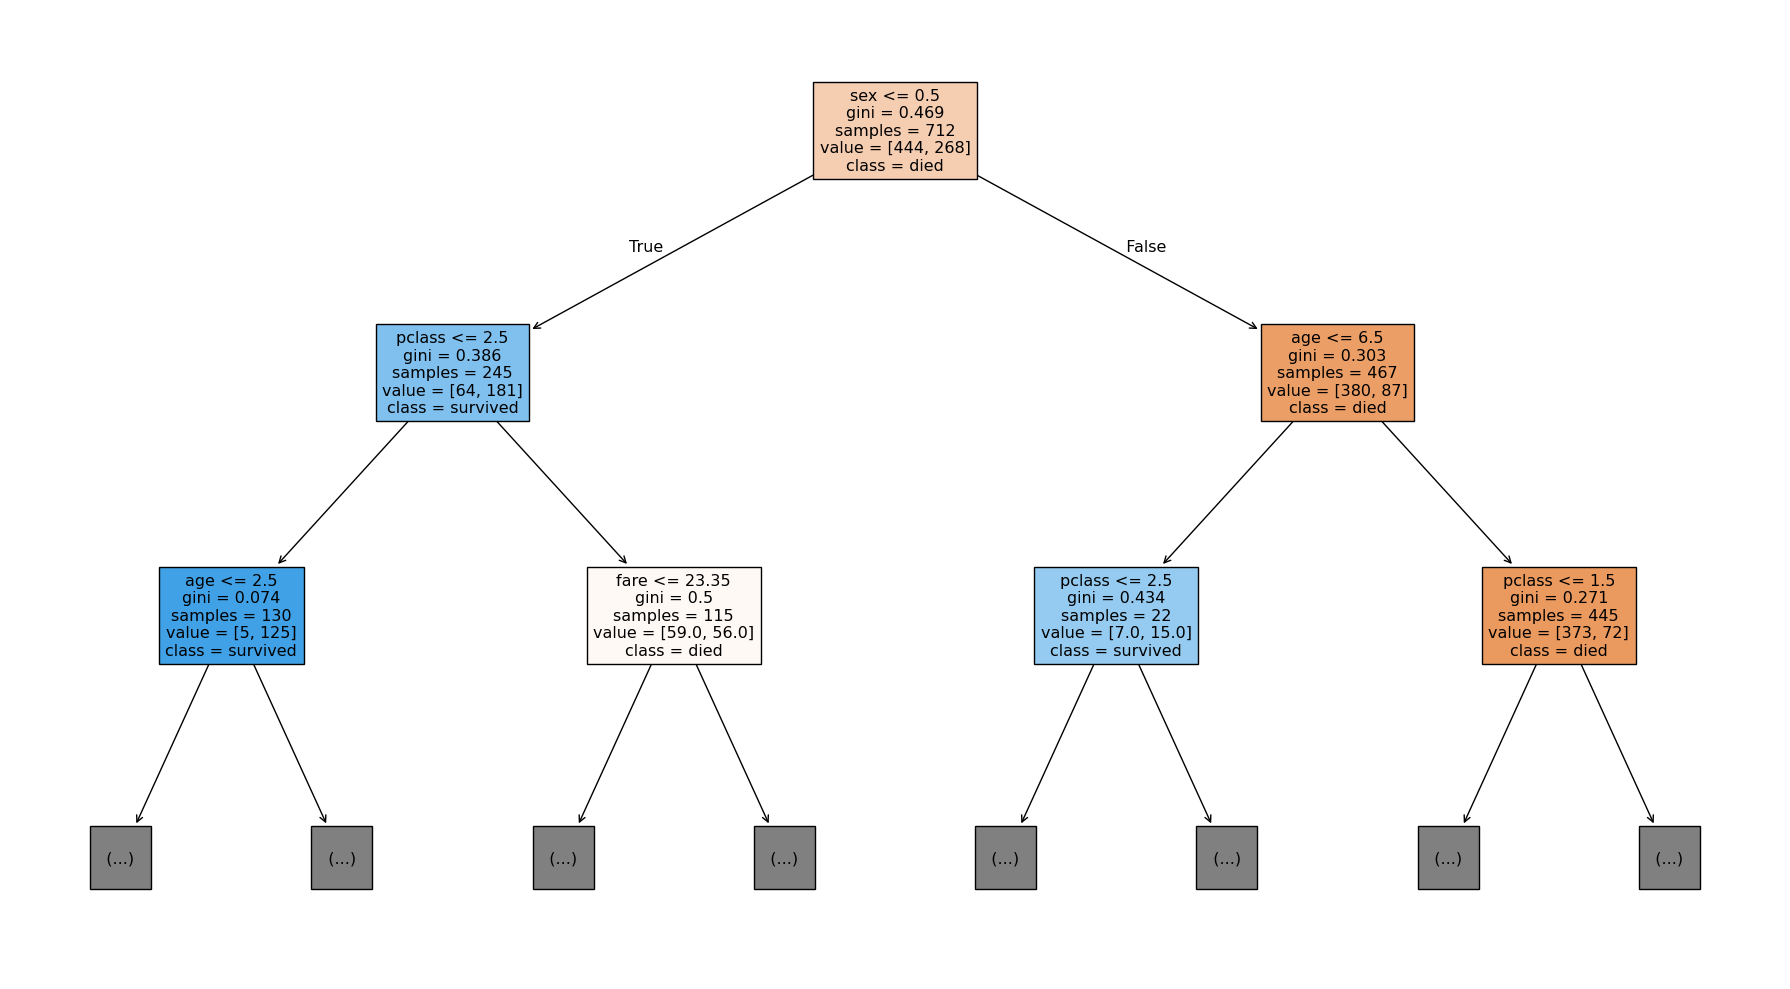

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names= x.columns,
    class_names = ["died","survived"],
    filled = True,
    max_depth =2
)
plt.tight_layout()
plt.show()

Decission Tree with pre-pruning



for depth = 2 , accuracy = 0.7653631284916201
for depth = 3 , accuracy = 0.7988826815642458
for depth = 4 , accuracy = 0.7988826815642458
for depth = 5 , accuracy = 0.7988826815642458
for depth = 6 , accuracy = 0.7988826815642458


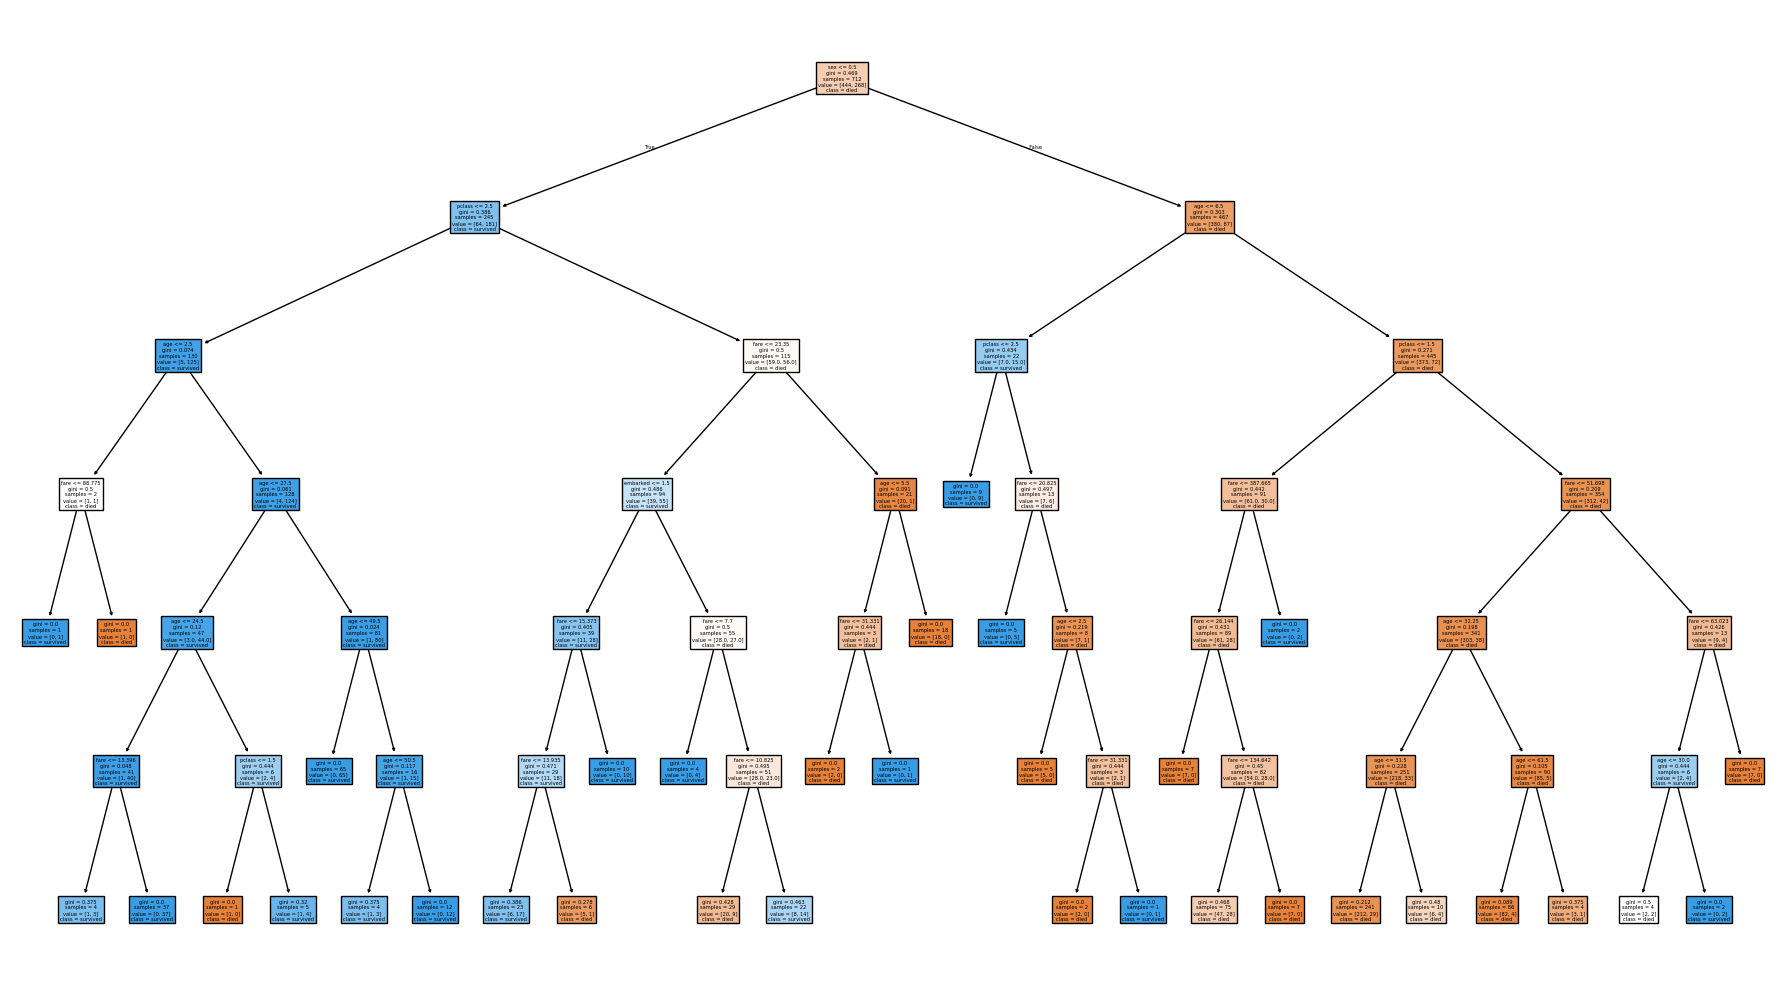

for depth = 7 , accuracy = 0.7932960893854749
for depth = 8 , accuracy = 0.7988826815642458
for depth = 9 , accuracy = 0.7932960893854749
for depth = 10 , accuracy = 0.7932960893854749


In [17]:
max_depths = [2,3,4,5,6,7,8,9,10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train,y_train)


    acc = model.score(x_test,y_test)
    print(f"for depth = {depth} , accuracy = {acc}")
    if depth == 6:
            plt.figure(figsize=(18,10))

            plot_tree(
                     model,
                        feature_names= x.columns,
                      class_names = ["died","survived"],
                         filled = True,
   
                          )
            plt.tight_layout()
            plt.show()



for sample split = 5 , accuracy = 0.8044692737430168
for sample split = 10 , accuracy = 0.8100558659217877


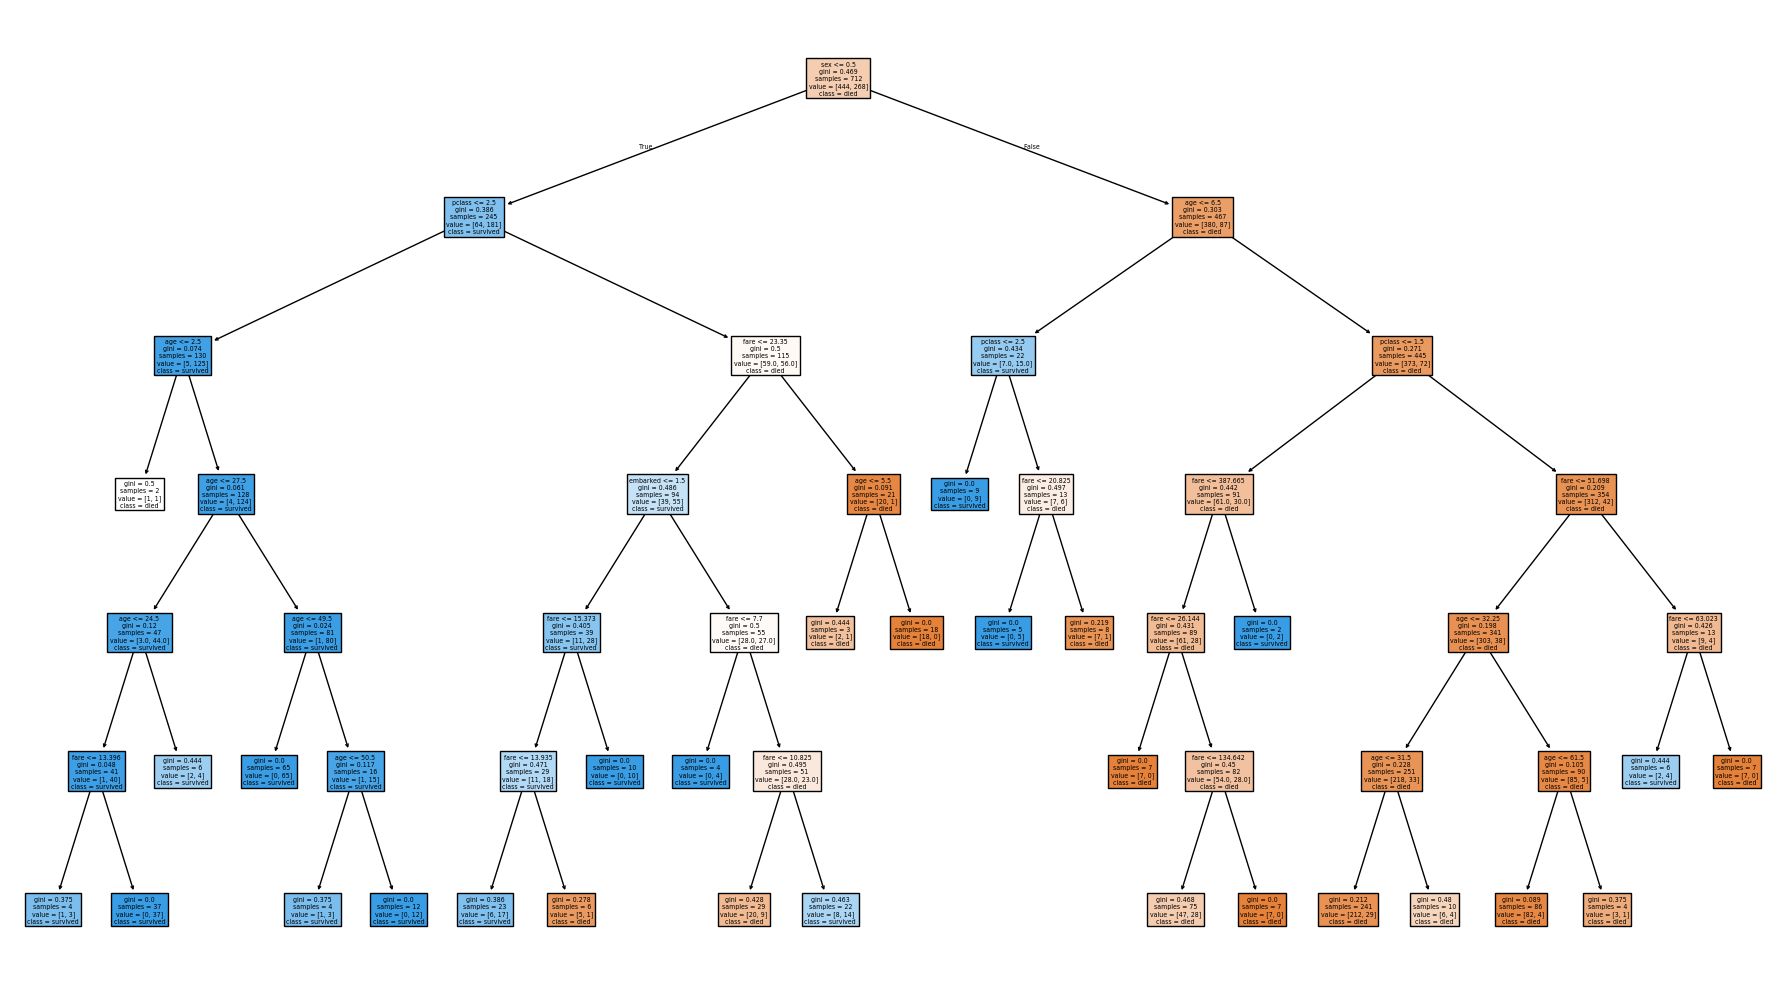

for sample split = 15 , accuracy = 0.8044692737430168
for sample split = 20 , accuracy = 0.8044692737430168
for sample split = 25 , accuracy = 0.7988826815642458
for sample split = 30 , accuracy = 0.7877094972067039


In [18]:
min_sample_splits = [5,10,15,20,25,30]

for split in min_sample_splits:
    model = DecisionTreeClassifier(max_depth= 6 ,min_samples_split=split )
    model.fit(x_train,y_train)


    acc = model.score(x_test,y_test)
    print(f"for sample split = {split} , accuracy = {acc}")
    if split == 10:
                plt.figure(figsize=(18,10))
    
                plot_tree(
                         model,
                            feature_names= x.columns,
                          class_names = ["died","survived"],
                             filled = True,
       
                              )
                plt.tight_layout()
                plt.show()

Decission Tree with post prunning

In [19]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [20]:
path  = full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas = path.ccp_alphas 
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [21]:
# train  our model for best alphas

trees =[]

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(x_train,y_train)

    trees.append((model,alpha))

#print(trees)

In [22]:
best_acc = 0
best_alpha =0

for model,alpha in trees:
    curr_acc = model.score(x_test, y_test)
    if curr_acc >  best_acc:
        best_acc = curr_acc
        best_alpha =  alpha
        

In [23]:
best_acc

0.8379888268156425

In [24]:
best_model = DecisionTreeClassifier(ccp_alpha= best_alpha)
best_model.fit(x_train,y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0015407231242023183))

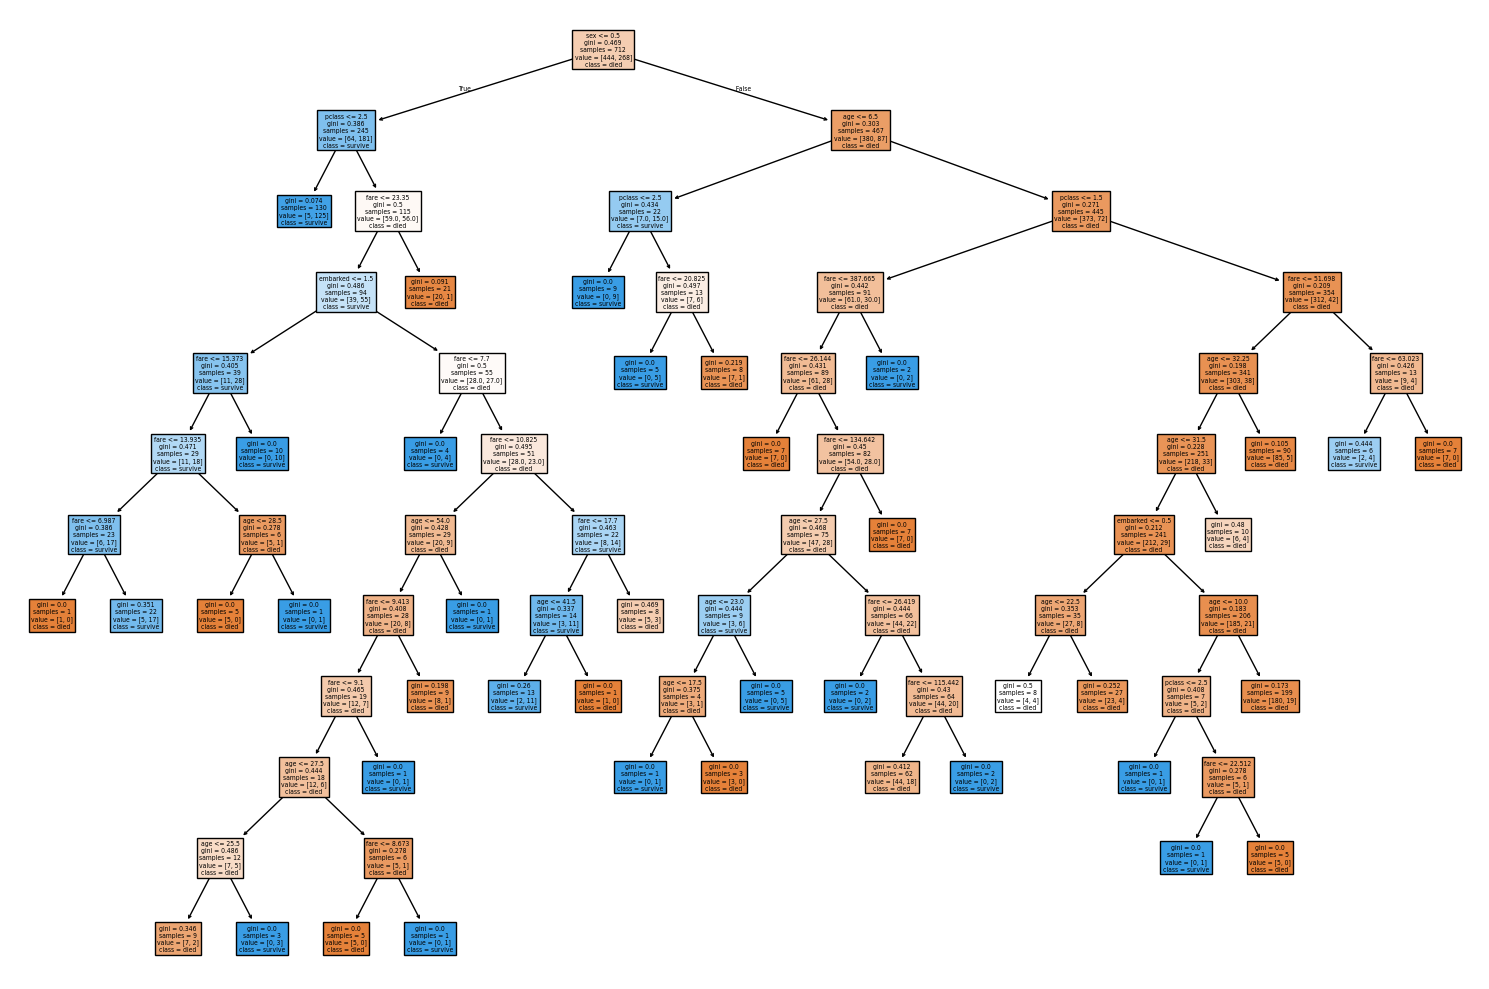

In [25]:
plt.figure(figsize=(15,10))
plot_tree(
    best_model,
    feature_names= x.columns,
    class_names= ['died',"survive"],
    filled= True
)
plt.tight_layout()
plt.show()

In [26]:
print(best_model.score(x_test,y_test))

0.8379888268156425


Random forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

bootstrap : deafult = True ,whether samples are used when building trees.if false the whole dataset is used to build each tree

oob_score  : default = False, it is used out of bag sample to estimate the generalization score

In [34]:
#Random forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators= 201,
    oob_score=True,
    max_depth=4
)

rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)

print("oob score :" , rf.oob_score_ *100 , "%")
print("testing acuuracy :" , accuracy_score(y_test,y_pred)*100, "%")

c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


oob score : 82.16292134831461 %
testing acuuracy : 81.00558659217877 %


Bagging with classifier and regressor


In [35]:
#Bagging classifier

from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)


bagging.fit(x_train,y_train)

y_pred  = bagging.predict(x_test)

print("accuracy : ", accuracy_score(y_test,y_pred))

c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


accuracy :  0.7988826815642458


In [36]:
#Logistic regression

from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)


bagging.fit(x_train,y_train)

y_pred  = bagging.predict(x_test)

print("accuracy : ", accuracy_score(y_test,y_pred))

c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


accuracy :  0.7988826815642458
